In [1]:
from RRTG_helpers import *
import pandas as pd
import numpy as np
import c_graph_lib.bin.tourny as tou

In [2]:
df = pd.read_csv("../Data/mlb_division_series_results.csv")
df = df.drop(columns=["league", "games_played", "ties", "wins2", "wins1"])
df

,season,division,team1,team2,result
0,1985,AL-East,BAL,BOS,BOS
1,1985,AL-East,BAL,CLE,BAL
2,1985,AL-East,BAL,DET,DET
3,1985,AL-East,BAL,MIL,BAL
4,1985,AL-East,BAL,NYA,NYA
...,...,...,...,...,...
2498,2024,NL-West,COL,SDN,COL
2499,2024,NL-West,COL,SFN,SFN
2500,2024,NL-West,LAN,SDN,SDN
2501,2024,NL-West,LAN,SFN,LAN


In [3]:
div_list = 	["AL-Central", "AL-East", "AL-West", "NL-Central", "NL-East", "NL-West"]

In [4]:
def df_to_tg(df: pd.DataFrame) -> DiGraph:
    
    tg_name: str = f"{df.iloc[int(0)]["division"]} {df.iloc[int(0)]["season"]}"
    edge_list: list[tuple[str, str]] = [
        (row["team1"], row["team2"]) if row["team1"] == row["result"]
        else (row["team2"], row["team1"])
        for (index, row) in df.iterrows()
    ]
    return DiGraph(edge_list,
                   data_structure="static_sparse", 
                   format="list_of_edges", 
                   name=tg_name)

In [5]:
df_year_list = list()
for i in range(1985, 2025):
    for div in div_list:
        tmp_df = df[(df["division"]==div) & (df["season"]==i)]
        if not tmp_df.empty:
            df_year_list.append(tmp_df)

tg_year_list = map(df_to_tg, df_year_list)
test = df_year_list[0]
test

,season,division,team1,team2,result
0,1985,AL-East,BAL,BOS,BOS
1,1985,AL-East,BAL,CLE,BAL
2,1985,AL-East,BAL,DET,DET
3,1985,AL-East,BAL,MIL,BAL
4,1985,AL-East,BAL,NYA,NYA
5,1985,AL-East,BAL,TOR,TOR
6,1985,AL-East,BOS,CLE,BOS
7,1985,AL-East,BOS,DET,DET
8,1985,AL-East,BOS,MIL,MIL
9,1985,AL-East,BOS,NYA,NYA


In [6]:
g = df_to_tg(test)

In [7]:
tourny_dict = {TG : list() for TG in digraphs.tournaments_nauty(5, immutable=True)}
tourny_dict

{Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: []}

In [9]:
for MLB_TG in tg_year_list:
    for g in tourny_dict:
        if MLB_TG.is_isomorphic(g):
            tourny_dict[g].append(MLB_TG)
            break

In [13]:
tourny_stats = [(g, len(tourny_dict[g]), num_upsets(g)) for g in tourny_dict]
tourny_stats

[(Digraph on 5 vertices, 50, 0),
 (Digraph on 5 vertices, 13, 0),
 (Digraph on 5 vertices, 22, 1),
 (Digraph on 5 vertices, 6, 2),
 (Digraph on 5 vertices, 7, 2),
 (Digraph on 5 vertices, 7, 2),
 (Digraph on 5 vertices, 7, 1),
 (Digraph on 5 vertices, 0, 0),
 (Digraph on 5 vertices, 17, 0),
 (Digraph on 5 vertices, 3, 1),
 (Digraph on 5 vertices, 11, 1),
 (Digraph on 5 vertices, 5, 0)]

Number of occurences in the data: 50	Number of upsets: 0


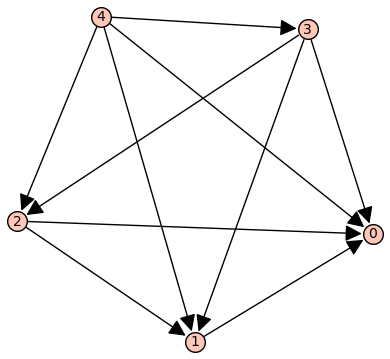

Number of occurences in the data: 13	Number of upsets: 0


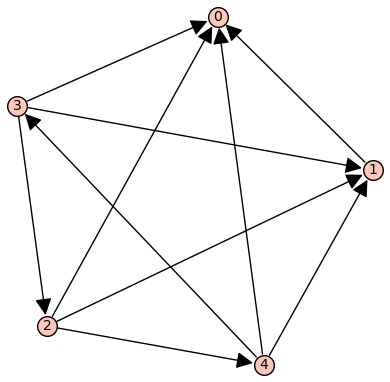

Number of occurences in the data: 22	Number of upsets: 1


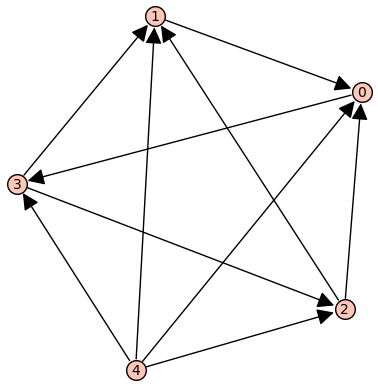

Number of occurences in the data: 6	Number of upsets: 2


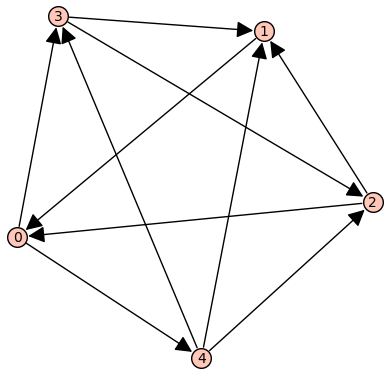

Number of occurences in the data: 7	Number of upsets: 2


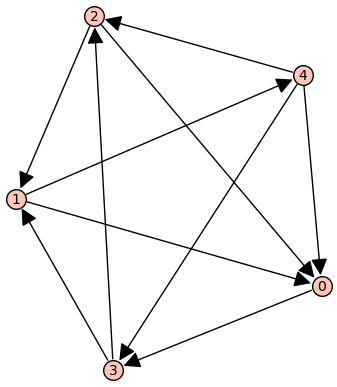

Number of occurences in the data: 7	Number of upsets: 2


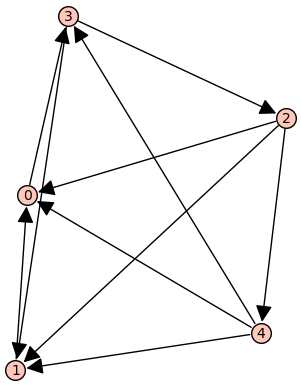

Number of occurences in the data: 7	Number of upsets: 1


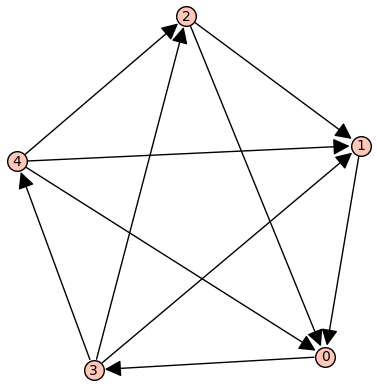

Number of occurences in the data: 0	Number of upsets: 0


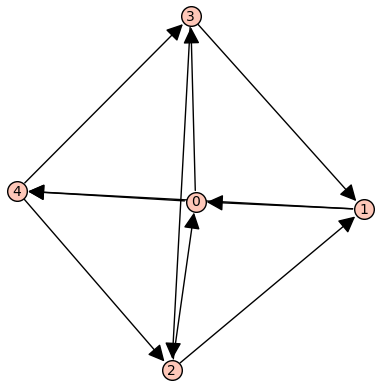

Number of occurences in the data: 17	Number of upsets: 0


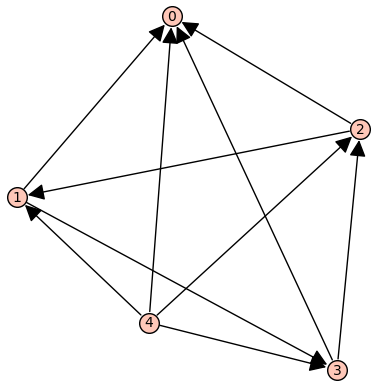

Number of occurences in the data: 3	Number of upsets: 1


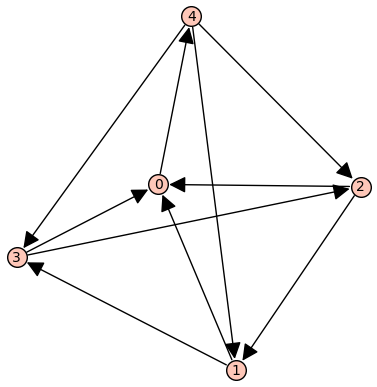

Number of occurences in the data: 11	Number of upsets: 1


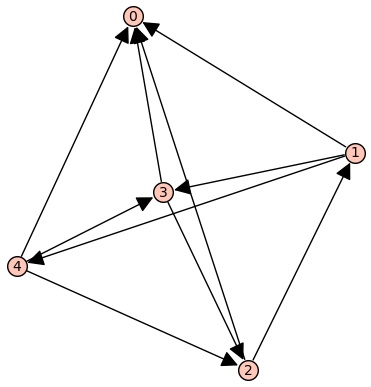

Number of occurences in the data: 5	Number of upsets: 0


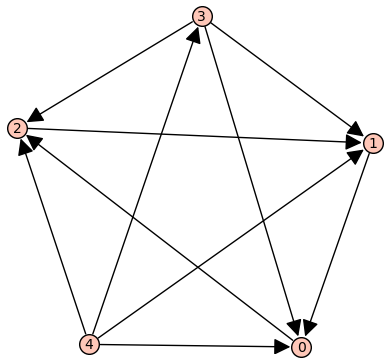

In [15]:
for g, n, u in tourny_stats:
    print(f"Number of occurences in the data: {n}\tNumber of upsets: {u}")
    show(g)

In [27]:
mlb_upset_list = list()

for g, n, u in tourny_stats:
    mlb_upset_list += ([u] * n)

83

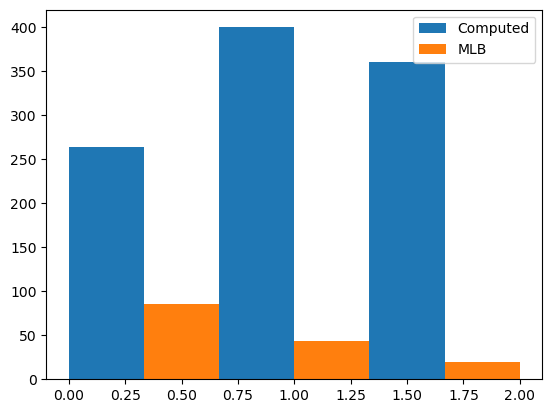

In [40]:
import matplotlib.pyplot as plt

plt.hist([full_list_upsets, mlb_upset_list], bins=3, label=['Computed', 'MLB'], align="mid", rwidth=1.0)
plt.legend(loc='upper right')
plt.show()

MLB:
$$\sigma^2 = 0.516572315558802,\ \mu = 0.5608108108108109$$
Computed:
$$\sigma^2 = 0.6005859375,\ \mu = 1.09375$$